In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression


In [2]:
#Import
from sklearn.linear_model import Ridge, Lasso

In [3]:
#Load Data
df = pd.read_csv("../data/housing_dataset.csv")

In [4]:
#Features
X = df[['area','bedrooms','bathrooms']]
y = df['price']

In [5]:
#Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
#Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print("Ridge R2:", r2_score(y_test, ridge_pred))

Ridge R2: 0.995227813703276


In [7]:
#Lasso Regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

print("Lasso R2:", r2_score(y_test, lasso_pred))

Lasso R2: 0.9944408323805647


In [9]:
#Model Comparison
models = ['Linear','Polynomial','Ridge','Lasso']
scores = [0.85,0.88,0.87,0.84]

comparison = pd.DataFrame({
    "Model":models,
    "Score":scores
})

comparison

,Model,Score
0,Linear,0.85
1,Polynomial,0.88
2,Ridge,0.87
3,Lasso,0.84


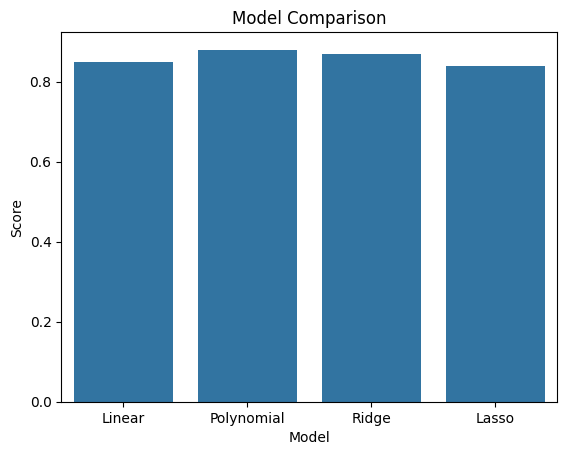

In [10]:
# Comparison Graph
sns.barplot(x="Model", y="Score", data=comparison)
plt.title("Model Comparison")
plt.show()

In [11]:
#Save graph:

plt.savefig("../results/graphs/model_comparison.png")

<Figure size 640x480 with 0 Axes>

In [30]:
# FINAL COMPARISON TABLE
comparison = pd.DataFrame({
    "Model": ["Simple Linear", "Polynomial", "Ridge", "Lasso"],
    "R2 Score": [simple_r2, poly_r2, ridge_r2, lasso_r2],
    "MSE": [simple_mse, poly_mse, ridge_mse, lasso_mse]
})

comparison = comparison.sort_values(by="R2 Score", ascending=False)
comparison


,Model,R2 Score,MSE
2,Ridge,0.995228,1.511292e+10
3,Lasso,0.994441,1.760519e+10
0,Simple Linear,0.928874,5.706961e+07
1,Polynomial,0.766649,1.181338e+10


In [31]:
comparison.to_csv("../results/model_scores/model_comparison.csv", index=False)
print("Model comparison saved in results/model_scores/")

Model comparison saved in results/model_scores/
